In [1]:
'''
import Libraries 
'''
import sys

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

import scipy
import statistics
from scipy.stats import zscore

sys.path.insert(1, 'G:/variational_inference/VIST_public/')
import VIST
import utils_timeseries

C:\Users\liamx\AppData\Roaming\Python\Python310\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
'''
load data
'''
anndata = sc.read_h5ad('G:/confidence_bound/rosbash_converted.h5ad')
anndata.obs['time_by_rep'] = anndata.obs.time2.copy(deep=True)
anndata.obs.time_by_rep[anndata.obs.Repeats == 'LD_2'] = anndata.obs.time_by_rep[anndata.obs.Repeats == 'LD_2'] + 24
anndata.obs.time_by_rep[anndata.obs.Repeats == 'DD_2'] = anndata.obs.time_by_rep[anndata.obs.Repeats == 'DD_2'] + 24



anndata = anndata[anndata.obs.experiment == 'CLK856_LD']
sc.pp.highly_variable_genes(anndata, flavor='seurat_v3', n_top_genes=2000)
gene_idx = anndata.var.highly_variable

anndata = anndata[:, gene_idx]
NvarGenes = gene_idx.sum()

timeDim = 32
Ndim = 8 + 1 #1 for the extra time dimension
smoothPower = 20
batchsize = 300



'''
initialize neural network
'''
model = VIST.VIST(NvarGenes, 
                256, 
                Ndim, 
                timeDim, 
                fixStd = True,
                fixVal = 0.5
                   ) 



C:\Users\liamx\AppData\Local\Temp\ipykernel_52552\2463552373.py:6: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  anndata.obs.time_by_rep[anndata.obs.Repeats == 'LD_2'] = anndata.obs.time_by_rep[anndata.obs.Repeats == 'LD_2'] + 24
C:\Users\li

In [ ]:
trained_model = VIST.train_net(anndata, model, 'time_by_rep', itr = 15000, model_name = 'G:/variational_inference/test2.pth', smoothPower=smoothPower)


g:\variational_inference\VIST_public\VIST.py:373: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  cellTime = torch.tensor(input_anndata.obs[time_field]).type(torch.float32)[random_sample]
g:\variational_inference\VIST_public\VIST.py:397: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sample_class = input_anndata.obs[time_field][random_sample]
g:\variational_inference\VIST_public\VIST.py:403: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


Iter: 0, loss_re: 0.4047, loss_log: 1.5040, loss KL: 263.5466, time prediction: 640.5854, wasserstein:0.1015


In [5]:
'''
visualize low dimensional structure
'''
from scipy.stats import zscore

X = torch.tensor(anndata.X.toarray()).type(torch.float32)
thisCell_hat = trained_model(X)

output_data = trained_model.latentMean(X)
output_data = output_data.detach().numpy()
output_raw = output_data.copy()[:,0:-1]


import umap as UM
reducer = UM.UMAP(n_neighbors=50, 
                  metric = 'euclidean', 
                  repulsion_strength=1, 
                  n_epochs=500, 
                  negative_sample_rate=5, 
                  min_dist = .5,
                  verbose = True,
                  random_state = 1
                 )

reducer2 = UM.UMAP(n_neighbors=5, 
                  metric = 'euclidean', 
                  repulsion_strength=1, 
                  n_epochs=1500, 
                  negative_sample_rate=5, 
                  min_dist = 0.5,
                  verbose = True,
                  random_state = 1
                 )

embedding_umap = reducer.fit_transform(zscore(output_raw))

KeyboardInterrupt: 

In [8]:
output_data[:,-1]

array([38.651623, 37.8753  , 35.255642, ..., 17.620989, 19.101187,
       19.328808], dtype=float32)

(4.2992037534713745,
 14.612765908241272,
 0.43787382543087006,
 10.939619973301888)

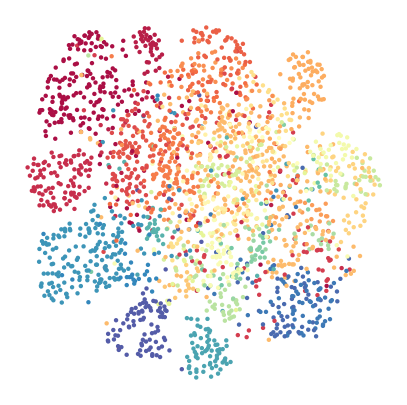

In [29]:
import seaborn as sns

cc = sns.color_palette('Spectral', 39)
brain_color_dict = {'1:DN1p_CNMa': cc[0],
                    '15:DN1p_CNMa': cc[1],
                    '3:DN1a': cc[2],
                    '14:DN3': cc[3],
                    '7:DN1p': cc[4],
                    '20:DN3': cc[5],
                    '6:DN1p': cc[6],
                    '18:DN1p': cc[7],
                    '4:DN1p': cc[8],
                    '19:DN2': cc[9],
                    '27': cc[10],
                    '16': cc[11],
                    '0': cc[12],
                    '31': cc[13],
                    '13': cc[14],
                    '22': cc[15],
                    '33': cc[16],
                    '21': cc[17],
                    '37': cc[18],
                    '32': cc[19],
                    '10': cc[20],
                    '23': cc[21],
                    '36': cc[22],
                    '17': cc[23],
                    '24': cc[24],
                    '28': cc[25],
                    '11': cc[26],
                    '30': cc[27],
                    '34': cc[28],
                    '26': cc[29],
                    '35': cc[30],
                    '38': cc[31],
                    '29:LPN': cc[32],
                    '8:LN_ITP': cc[33],
                    '2:s_LNv': cc[34],
                    '25:l_LNv': cc[35],
                    '9:LNd_NPF': cc[36],
                    '12:LNd': cc[37],
                    '5:LNd_Trissin': cc[38],
                   
                   }


df = pd.DataFrame(dict(
                       x_umap = embedding_umap[:,0],
                       y_umap = embedding_umap[:,1],
                       cellType = anndata.obs.Idents
                      )
                 )


'''
plot cell type
'''
fig = sns.scatterplot(df, x = 'x_umap', y = 'y_umap', hue = 'cellType', 
                      linewidth = 0, legend=False, 
                      palette=brain_color_dict, s = 10)
plt.gcf().set_size_inches(5,5)
plt.axis('off')

In [41]:
if scipy.sparse.issparse(anndata.X):
    anndata.X = anndata.X.toarray()

anndata.X

<2325x2000 sparse matrix of type '<class 'numpy.float64'>'
	with 796352 stored elements in Compressed Sparse Row format>

In [ ]:
''' 
visualize time series
'''
import importlib

importlib.reload(utils_timeseries)

cell_type = '1:DN1p_CNMa'
# cell_type = '4:DN1p'
# cell_type = '15:DN1p_CNMa' # can show the importance of larger std with tim
# cell_type = '2:s_LNv'

test_time = torch.tensor(torch.linspace(0,48,500))


rho = utils_timeseries.df_timeSeries(cell_type, trained_model, anndata, test_time)



C:\Users\liamx\AppData\Local\Temp\ipykernel_31224\9785366.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_time = torch.tensor(torch.linspace(0,48,500))


In [60]:
gene_use = 'vri'
gene_loc = (anndata.var_names == gene_use)
df_model = utils_timeseries.construct_df(rho, gene_loc, test_time)

c:\Users\liamx\anaconda3\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\liamx\anaconda3\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\liamx\anaconda3\lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


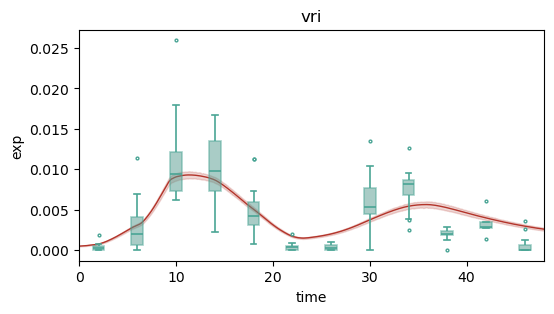

In [61]:
color_dict = {'generated': '#B3342A',
              'observed': '#4AA595'
             }

def normalize_count(raw_mat):
    cell_count = raw_mat.sum(axis = 1)
    normalize_by_total = (raw_mat / cell_count[:,None]) 
    zscored_data = zscore(normalize_by_total, axis = 0)
    
    return normalize_by_total

GENE_EXP = normalize_count(anndata.X.toarray())

time_for_df = np.float32(anndata.obs.time_by_rep[anndata.obs.Idents == cell_type].values)
exp_for_df =  GENE_EXP[anndata.obs.Idents == cell_type, gene_loc]
type_for_df = np.repeat("observed", len(anndata.obs.time_by_rep[anndata.obs.Idents == cell_type].values))


df = pd.DataFrame(dict(time = time_for_df,
                       exp = exp_for_df,
                       TYPE = type_for_df,
                      )
                 )


f1 = sns.lineplot(data = df_model, x = 'time', y = 'exp', 
                  hue = 'TYPE', 
                  palette = color_dict, linewidth=1, legend = False, 
                 )

sns.boxplot(df, x = 'time', y = 'exp', hue = 'TYPE', 
                 palette=color_dict, fliersize=2,  
                 boxprops=dict(alpha=.5), 
                 linewidth=1.2, native_scale = True, linecolor="#4AA595", width = 0.3, legend = False)

plt.gcf().set_size_inches(6,3)
plt.title(gene_use)
#plt.ylim(0,0.04)
plt.xlim(0,48)

# plt.savefig('G:/variational_inference/figure_making/fig5_related/clus_2_ddc.pdf', bbox_inches='tight', dpi = 600)
plt.show()